In [1]:
!pip install highlight-text

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import highlight_text

In [3]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
  return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

In [4]:
df = pd.read_csv('/content/drive/MyDrive/F_Data_Academy/beeswarmTutorial.csv')

In [5]:
text_color = 'white'
background = '#313332'

In [6]:
df.head()

,Player,Pos,Squad,90s,Prog
0,Patrick van Aanholt\Patrick-van-Aanholt,DF,Crystal Palace,11.7,76
1,Tammy Abraham\Tammy-Abraham,FW,Chelsea,10.6,11
2,Che Adams\Che-Adams,FW,Southampton,19.0,38
3,Tosin Adarabioyo\Tosin-Adarabioyo,DF,Fulham,18.0,36
4,Adrián\Adrian,GK,Liverpool,2.0,0


In [7]:
df['per90'] = df['Prog']/df['90s']
df

,Player,Pos,Squad,90s,Prog,per90
0,Patrick van Aanholt\Patrick-van-Aanholt,DF,Crystal Palace,11.7,76,6.495726
1,Tammy Abraham\Tammy-Abraham,FW,Chelsea,10.6,11,1.037736
2,Che Adams\Che-Adams,FW,Southampton,19.0,38,2.000000
3,Tosin Adarabioyo\Tosin-Adarabioyo,DF,Fulham,18.0,36,2.000000
4,Adrián\Adrian,GK,Liverpool,2.0,0,0.000000
...,...,...,...,...,...,...
492,Andre-Frank Zambo Anguissa\Andre-Frank-Zambo-A...,MF,Fulham,18.7,74,3.957219
493,Andi Zeqiri\Andi-Zeqiri,FWDF,Brighton,0.8,1,1.250000
494,Oleksandr Zinchenko\Oleksandr-Zinchenko,DF,Manchester City,7.1,39,5.492958
495,Hakim Ziyech\Hakim-Ziyech,FWMF,Chelsea,7.0,42,6.000000


In [8]:
df = df[df['90s']>=6.5].reset_index()
df

,index,Player,Pos,Squad,90s,Prog,per90
0,0,Patrick van Aanholt\Patrick-van-Aanholt,DF,Crystal Palace,11.7,76,6.495726
1,1,Tammy Abraham\Tammy-Abraham,FW,Chelsea,10.6,11,1.037736
2,2,Che Adams\Che-Adams,FW,Southampton,19.0,38,2.000000
3,3,Tosin Adarabioyo\Tosin-Adarabioyo,DF,Fulham,18.0,36,2.000000
4,6,Ola Aina\Ola-Aina,DF,Fulham,17.7,69,3.898305
...,...,...,...,...,...,...,...
300,491,Wilfried Zaha\Wilfried-Zaha,FW,Crystal Palace,18.5,39,2.108108
301,492,Andre-Frank Zambo Anguissa\Andre-Frank-Zambo-A...,MF,Fulham,18.7,74,3.957219
302,494,Oleksandr Zinchenko\Oleksandr-Zinchenko,DF,Manchester City,7.1,39,5.492958
303,495,Hakim Ziyech\Hakim-Ziyech,FWMF,Chelsea,7.0,42,6.000000


In [9]:
df.describe()

,index,90s,Prog,per90
count,305.000000,305.000000,305.000000,305.000000
mean,241.468852,14.688525,43.655738,3.019502
std,146.384632,4.758721,31.651934,1.798697
min,0.000000,6.600000,0.000000,0.000000
25%,110.000000,10.900000,21.000000,1.932773
50%,243.000000,14.700000,37.000000,2.857143
75%,371.000000,18.800000,60.000000,4.000000
max,496.000000,23.000000,171.000000,9.879518


In [10]:
df = df.sort_values(by='per90',ascending=False)

In [11]:
df = df[df['Pos'] != 'GK']

In [12]:
df.head(10)

,index,Player,Pos,Squad,90s,Prog,per90
8,11,Thiago Alcántara\Thiago-Alcantara,MF,Liverpool,8.3,82,9.879518
10,14,Trent Alexander-Arnold\Trent-Alexander-Arnold,DF,Liverpool,19.5,166,8.512821
148,234,Mateo Kovačić\Mateo-Kovacic,MF,Chelsea,13.1,105,8.015267
299,487,Granit Xhaka\Granit-Xhaka,MF,Arsenal,17.1,136,7.953216
122,187,Jordan Henderson\Jordan-Henderson,MFDF,Liverpool,17.6,134,7.613636
77,111,Kevin De Bruyne\Kevin-De-Bruyne,MF,Manchester City,15.6,118,7.564103
190,301,James Milner\James-Milner,MFDF,Liverpool,6.8,51,7.500000
230,375,Andrew Robertson\Andrew-Robertson,DF,Liverpool,22.9,171,7.467249
236,384,James Rodríguez\James-Rodriguez,FWMF,Everton,13.3,99,7.443609
96,140,Bruno Fernandes\Bruno-Fernandes,MF,Manchester Utd,21.4,158,7.383178


Text(0.5, 25.722222222222214, 'Pases progresivos por 90')

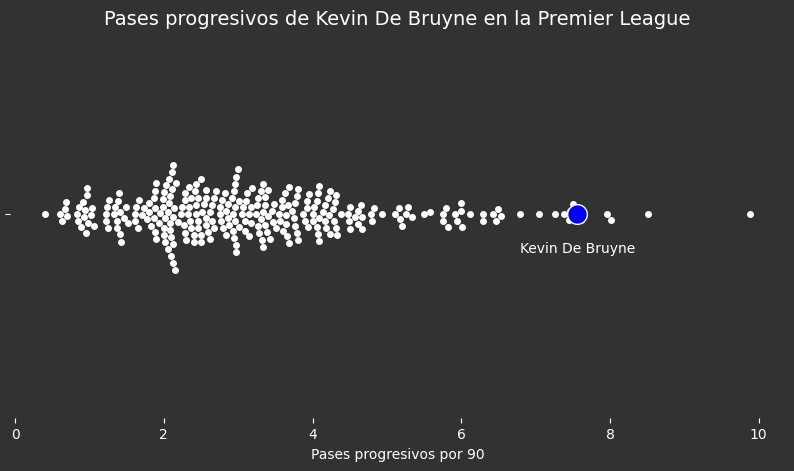

In [16]:
fig, ax = plt.subplots(figsize=(10,5))
fig.set_facecolor(background)
ax.patch.set_facecolor(background)

mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

ax.grid(ls='dotted',lw=.5,color='lightgrey',axis='y',zorder=1)
spines = ['top','bottom','left','right']
for x in spines:
  if x in spines:
    ax.spines[x].set_visible(False)

sns.swarmplot(x='per90',data=df,color='white',zorder=1)

plt.scatter(x=7.56, y=0,c='blue',edgecolor='white',s=200,zorder=2)
ax.annotate(
    'Kevin De Bruyne',
    xy=(7.56, 0),
    xytext=(0, -20),
    textcoords='offset points',
    color=text_color,
    ha='center',
    va='top',
    fontsize=10
)

plt.title('Pases progresivos de Kevin De Bruyne en la Premier League',c=text_color,fontsize=14)

plt.xlabel('Pases progresivos por 90',c=text_color)

Text(0.5, 25.722222222222214, 'Pases progresivos por 90')

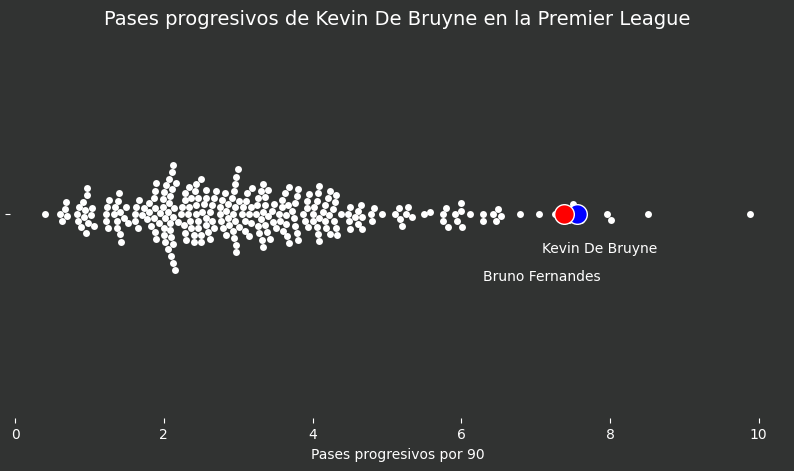

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
fig.set_facecolor(background)
ax.patch.set_facecolor(background)

mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

ax.grid(ls='dotted',lw=.5,color='lightgrey',axis='y',zorder=1)
spines = ['top','bottom','left','right']
for x in spines:
  if x in spines:
    ax.spines[x].set_visible(False)

sns.swarmplot(x='per90',data=df,color='white',zorder=1)

plt.scatter(x=7.56, y=0,c='blue',edgecolor='white',s=200,zorder=2)
ax.annotate(
    'Kevin De Bruyne',
    xy=(7.86, 0),
    xytext=(0, -20),
    textcoords='offset points',
    color=text_color,
    ha='center',
    va='top',
    fontsize=10
)

plt.scatter(x=7.38, y=0,c='red',edgecolor='white',s=200,zorder=2)
ax.annotate(
    'Bruno Fernandes',
    xy=(7.08, 0),
    xytext=(0, -40),
    textcoords='offset points',
    color=text_color,
    ha='center',
    va='top',
    fontsize=10
)

plt.title('Pases progresivos de Kevin De Bruyne en la Premier League',c=text_color,fontsize=14)

plt.xlabel('Pases progresivos por 90',c=text_color)